Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [ ]:
cars = pd.read_csv('/content/cars.csv')
cars

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1,Toyota,Corolla,2018,50000,Petrol,Manual,First,15,1498,108,5,800000
1,2,Honda,Civic,2019,40000,Petrol,Automatic,Second,17,1597,140,5,1000000
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4,2500000
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5,600000
4,5,Hyundai,Sonata,2016,60000,Diesel,Automatic,Second,18,1999,194,5,850000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,Mercedes,C-Class,2019,22000,Diesel,Automatic,First,16,1950,191,5,2900000
96,97,Toyota,Innova Crysta,2017,38000,Diesel,Manual,Second,13,2755,171,7,1400000
97,98,Ford,EcoSport,2018,26000,Petrol,Manual,Third,18,1497,121,5,750000
98,99,Hyundai,Verna,2019,24000,Petrol,Automatic,Second,17,1497,113,5,850000


 Exploratory data analysis

In [ ]:
cars.shape

(100, 13)

In [ ]:
cars.columns

Index(['Car_ID', 'Brand', 'Model', 'Year', 'Kilometers_Driven', 'Fuel_Type',
       'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats',
       'Price'],
      dtype='object')

In [ ]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Car_ID             100 non-null    int64 
 1   Brand              100 non-null    object
 2   Model              100 non-null    object
 3   Year               100 non-null    int64 
 4   Kilometers_Driven  100 non-null    int64 
 5   Fuel_Type          100 non-null    object
 6   Transmission       100 non-null    object
 7   Owner_Type         100 non-null    object
 8   Mileage            100 non-null    int64 
 9   Engine             100 non-null    int64 
 10  Power              100 non-null    int64 
 11  Seats              100 non-null    int64 
 12  Price              100 non-null    int64 
dtypes: int64(8), object(5)
memory usage: 10.3+ KB


In [ ]:
cars.describe()

,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Price
count,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,100.000000,1.000000e+02
mean,50.500000,2018.39000,28150.000000,17.210000,1855.230000,158.130000,5.230000,1.574000e+06
std,29.011492,1.17116,9121.375716,3.309902,631.311475,76.968137,0.750151,1.000265e+06
min,1.000000,2016.00000,10000.000000,10.000000,999.000000,68.000000,4.000000,4.500000e+05
25%,25.750000,2017.75000,22000.000000,15.000000,1462.000000,103.000000,5.000000,7.000000e+05
50%,50.500000,2018.00000,27000.000000,17.000000,1774.000000,148.000000,5.000000,1.300000e+06
75%,75.250000,2019.00000,32000.000000,19.000000,2143.000000,187.000000,5.000000,2.500000e+06
max,100.000000,2021.00000,60000.000000,25.000000,4951.000000,396.000000,7.000000,4.000000e+06


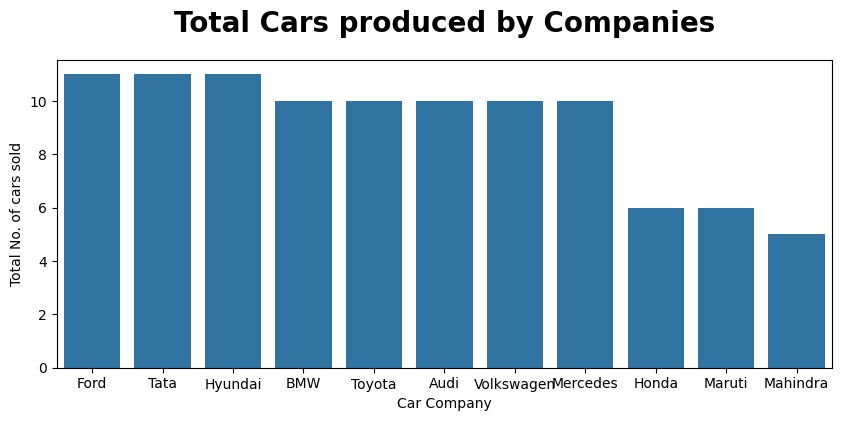

In [ ]:
plt.figure(figsize=(10,4))
counts = cars["Brand"].value_counts()
sns.barplot(x=counts.index, y=counts.values)
plt.xlabel("Car Company")
plt.ylabel("Total No. of cars sold")
plt.title("Total Cars produced by Companies", pad=20, fontweight="black", fontsize=20)
plt.show()


Our target variable is the Price column. So, I will check its distribution.

In [ ]:
cars['Price'].describe()

,Price
count,1.000000e+02
mean,1.574000e+06
std,1.000265e+06
min,4.500000e+05
25%,7.000000e+05
50%,1.300000e+06
75%,2.500000e+06
max,4.000000e+06


In [ ]:
cars["Price"].agg(["min","mean","median","max","std","skew"]).to_frame().T

,min,mean,median,max,std,skew
Price,450000.0,1574000.0,1300000.0,4000000.0,1.000265e+06,0.614286


Explore missing values in variables


In [ ]:
cars.isnull().sum()

,0
Car_ID,0
Brand,0
Model,0
Year,0
Kilometers_Driven,0
Fuel_Type,0
Transmission,0
Owner_Type,0
Mileage,0
Engine,0


In [ ]:
cars.duplicated().sum()

np.int64(0)

There are no missing values in the dataset.


Outliers in numerical variables



In [ ]:
round(cars.describe(),2)

,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Price
count,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
mean,50.50,2018.39,28150.00,17.21,1855.23,158.13,5.23,1574000.00
std,29.01,1.17,9121.38,3.31,631.31,76.97,0.75,1000264.61
min,1.00,2016.00,10000.00,10.00,999.00,68.00,4.00,450000.00
25%,25.75,2017.75,22000.00,15.00,1462.00,103.00,5.00,700000.00
50%,50.50,2018.00,27000.00,17.00,1774.00,148.00,5.00,1300000.00
75%,75.25,2019.00,32000.00,19.00,2143.00,187.00,5.00,2500000.00
max,100.00,2021.00,60000.00,25.00,4951.00,396.00,7.00,4000000.00


Text(0, 0.5, 'Price')

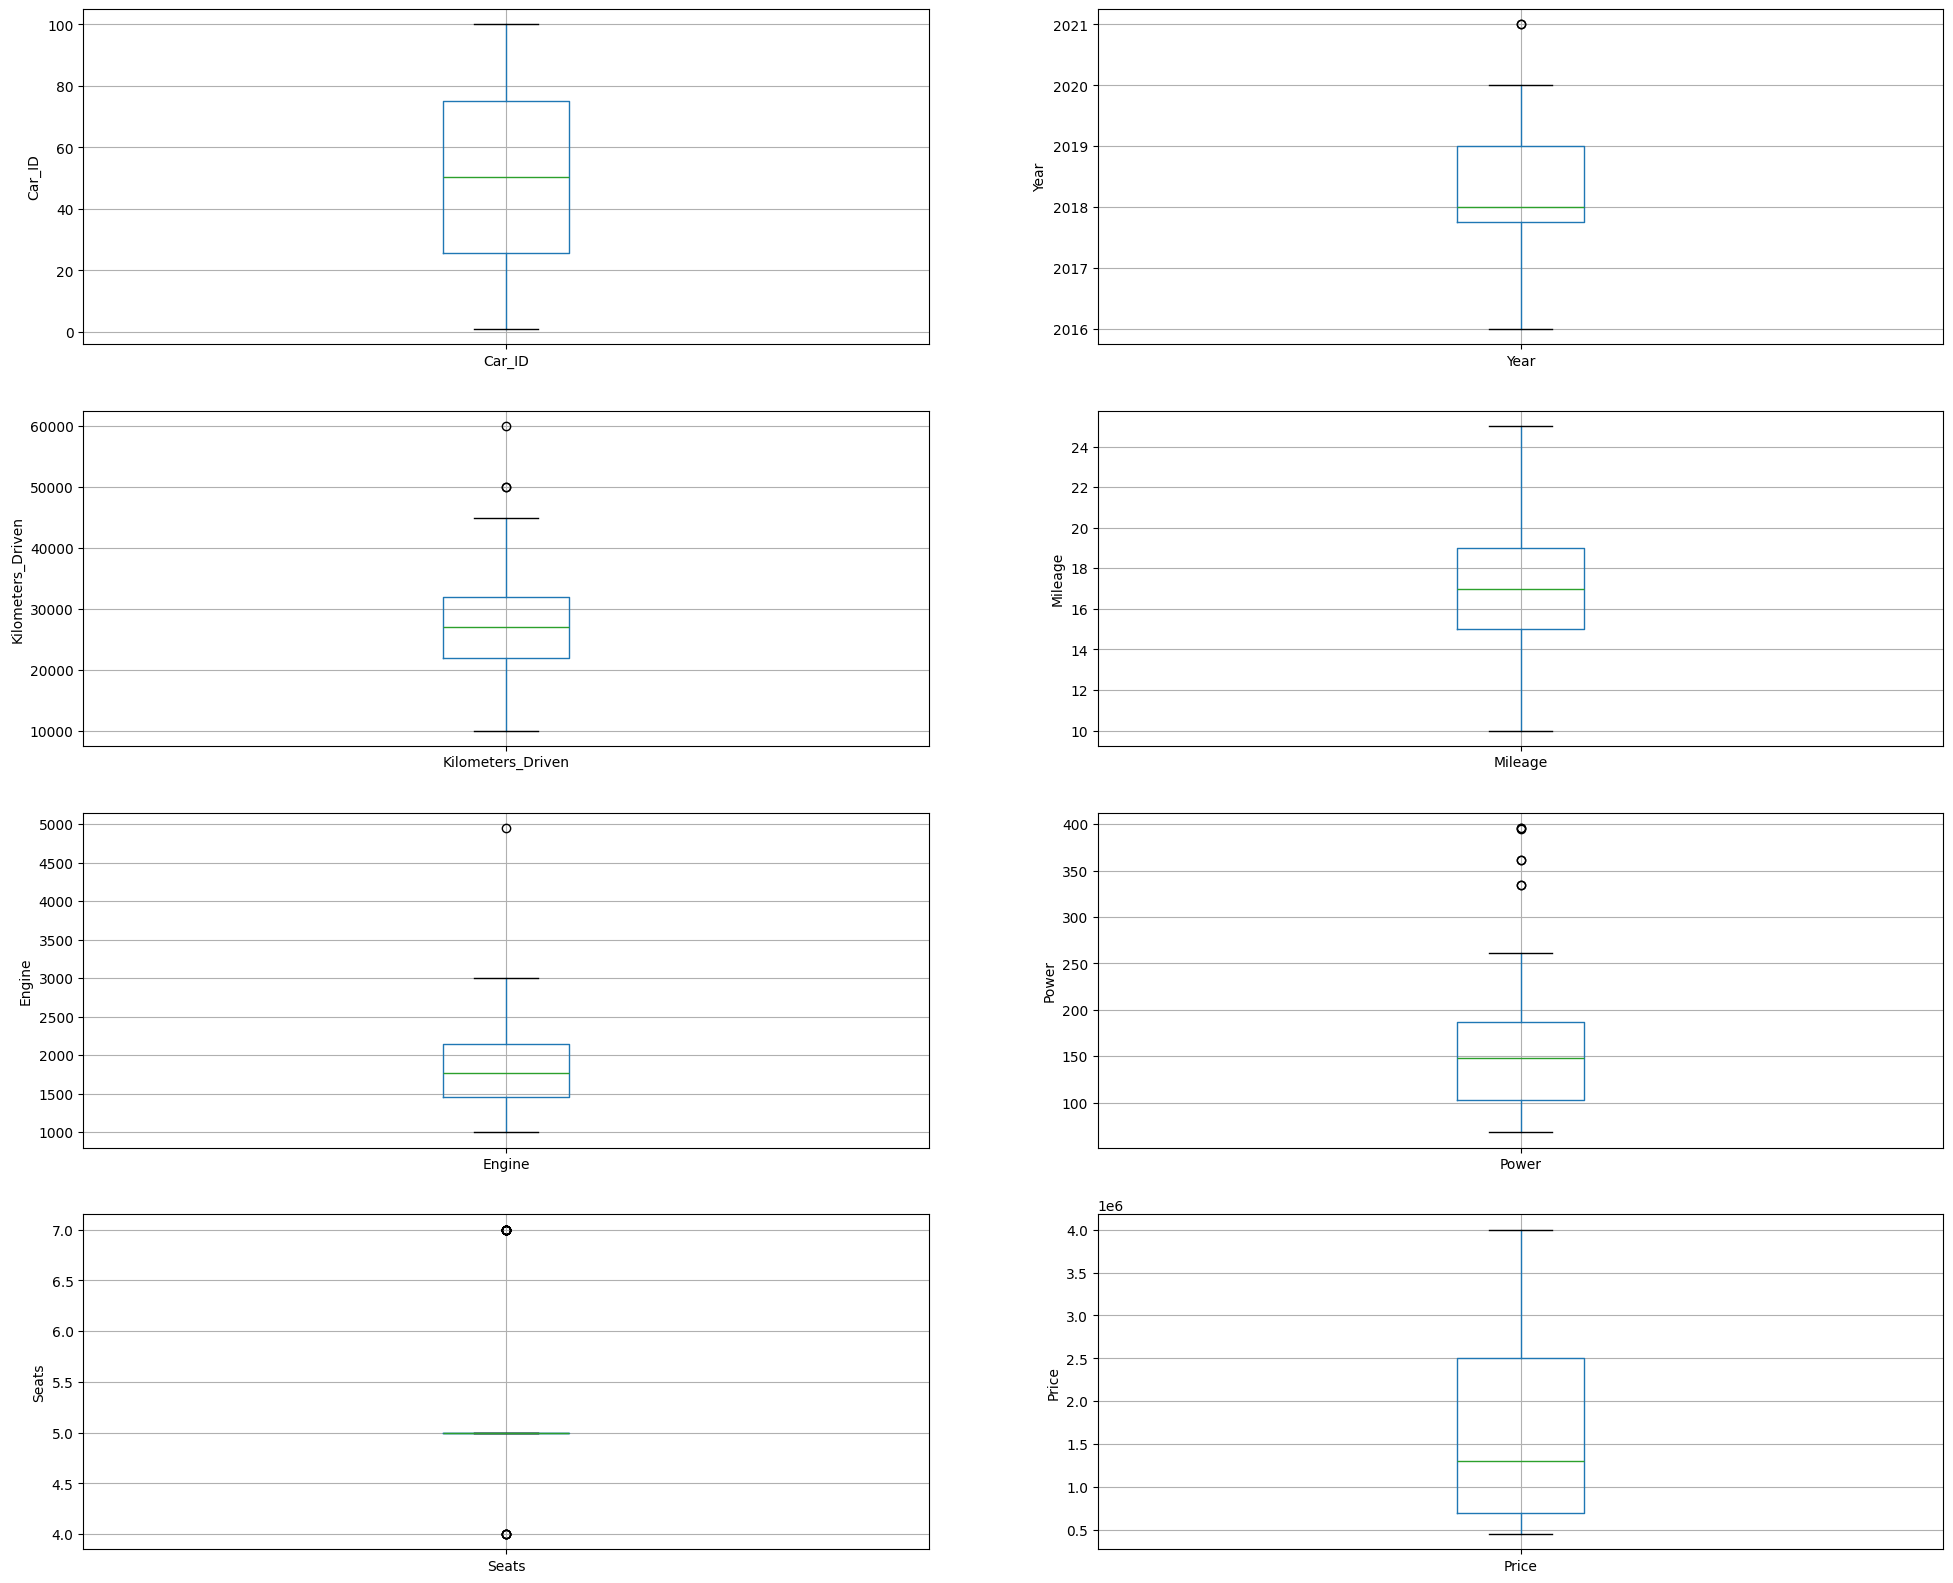

In [ ]:
# draw boxplots to visualize outliers

plt.figure(figsize=(24,20))


plt.subplot(4, 2, 1)
fig = cars.boxplot(column='Car_ID')
fig.set_title('')
fig.set_ylabel('Car_ID')


plt.subplot(4, 2, 2)
fig = cars.boxplot(column='Year')
fig.set_title('')
fig.set_ylabel('Year')


plt.subplot(4, 2, 3)
fig = cars.boxplot(column='Kilometers_Driven')
fig.set_title('')
fig.set_ylabel('Kilometers_Driven')


plt.subplot(4, 2, 4)
fig = cars.boxplot(column='Mileage')
fig.set_title('')
fig.set_ylabel('Mileage')


plt.subplot(4, 2, 5)
fig = cars.boxplot(column='Engine')
fig.set_title('')
fig.set_ylabel('Engine')


plt.subplot(4, 2, 6)
fig = cars.boxplot(column='Power')
fig.set_title('')
fig.set_ylabel('Power')


plt.subplot(4, 2, 7)
fig = cars.boxplot(column='Seats')
fig.set_title('')
fig.set_ylabel('Seats')


plt.subplot(4, 2, 8)
fig = cars.boxplot(column='Price')
fig.set_title('')
fig.set_ylabel('Price')

Text(0, 0.5, 'Number of cars')

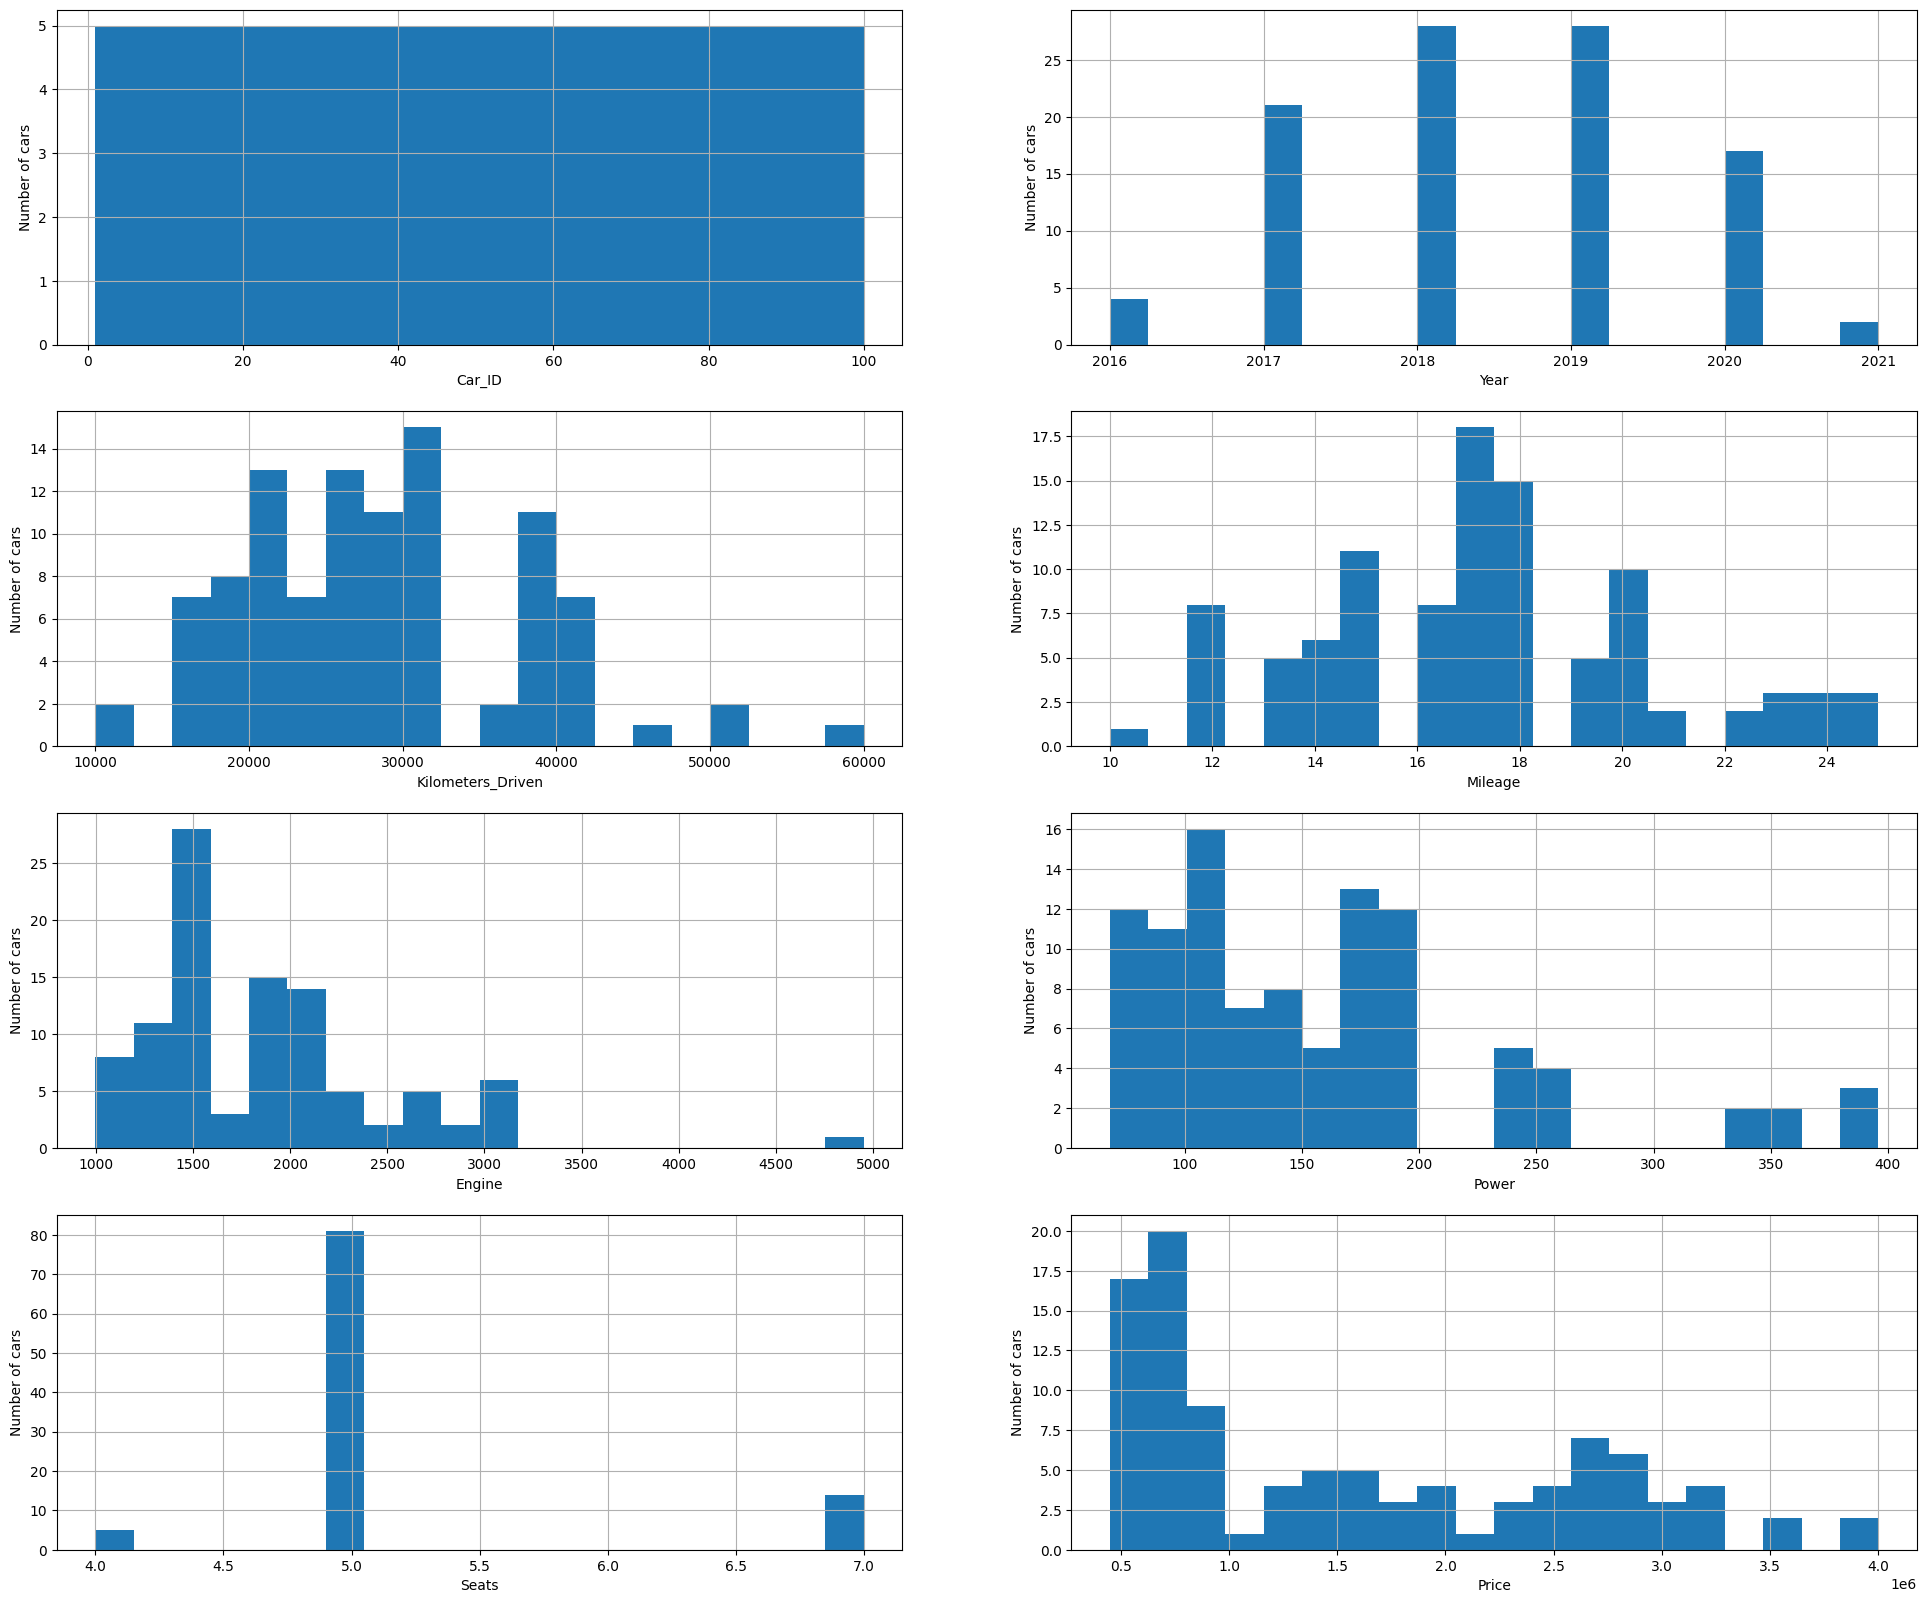

In [ ]:
# plot histogram to check distribution


plt.figure(figsize=(24,20))


plt.subplot(4, 2, 1)
fig = cars['Car_ID'].hist(bins=20)
fig.set_xlabel('Car_ID')
fig.set_ylabel('Number of cars')


plt.subplot(4, 2, 2)
fig = cars['Year'].hist(bins=20)
fig.set_xlabel('Year')
fig.set_ylabel('Number of cars')


plt.subplot(4, 2, 3)
fig = cars['Kilometers_Driven'].hist(bins=20)
fig.set_xlabel('Kilometers_Driven')
fig.set_ylabel('Number of cars')



plt.subplot(4, 2, 4)
fig = cars['Mileage'].hist(bins=20)
fig.set_xlabel('Mileage')
fig.set_ylabel('Number of cars')



plt.subplot(4, 2, 5)
fig = cars['Engine'].hist(bins=20)
fig.set_xlabel('Engine')
fig.set_ylabel('Number of cars')



plt.subplot(4, 2, 6)
fig = cars['Power'].hist(bins=20)
fig.set_xlabel('Power')
fig.set_ylabel('Number of cars')



plt.subplot(4, 2, 7)
fig = cars['Seats'].hist(bins=20)
fig.set_xlabel('Seats')
fig.set_ylabel('Number of cars')


plt.subplot(4, 2, 8)
fig = cars['Price'].hist(bins=20)
fig.set_xlabel('Price')
fig.set_ylabel('Number of cars')


Drop Unnecessary Column

In [ ]:
cars.drop("Car_ID", axis=1, inplace=True)

In [ ]:
cars.columns

Index(['Brand', 'Model', 'Year', 'Kilometers_Driven', 'Fuel_Type',
       'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats',
       'Price'],
      dtype='object')

Analysis

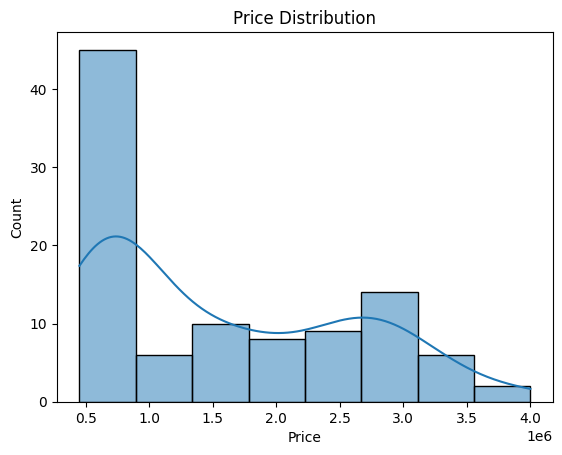

In [ ]:
sns.histplot(cars["Price"], kde=True)
plt.title("Price Distribution")
plt.show()

This plot shows how car prices are distributed in the dataset. Most cars fall in the mid-price range, with a few high-priced cars acting as outliers.

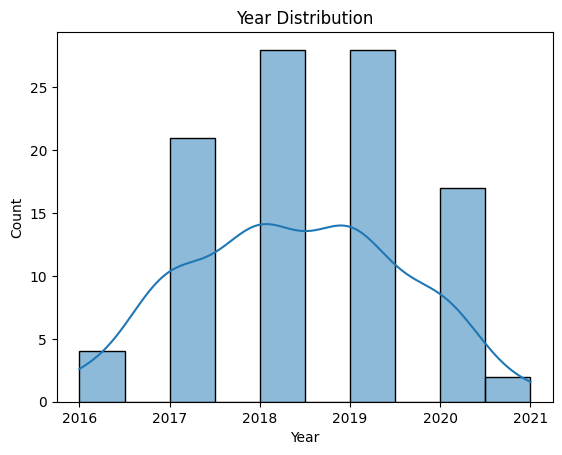

In [ ]:
sns.histplot(cars["Year"], kde=True)
plt.title("Year Distribution")
plt.show()

This graph shows the manufacturing years of cars. Most cars are from recent years, indicating a relatively modern dataset.

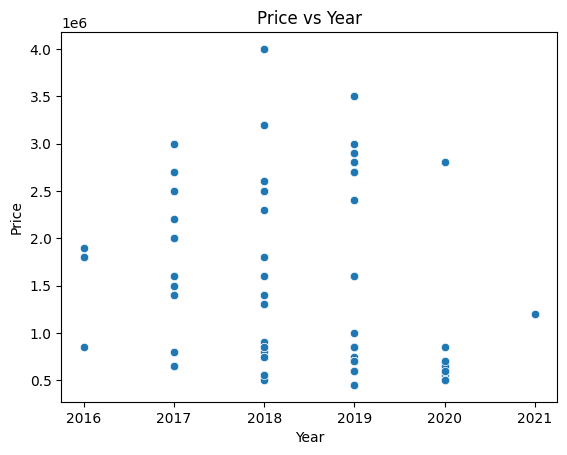

In [ ]:
sns.scatterplot(x="Year", y="Price", data=cars)
plt.title("Price vs Year")
plt.show()

This plot shows a positive relationship between year and price. Newer cars generally have higher prices compared to older cars.

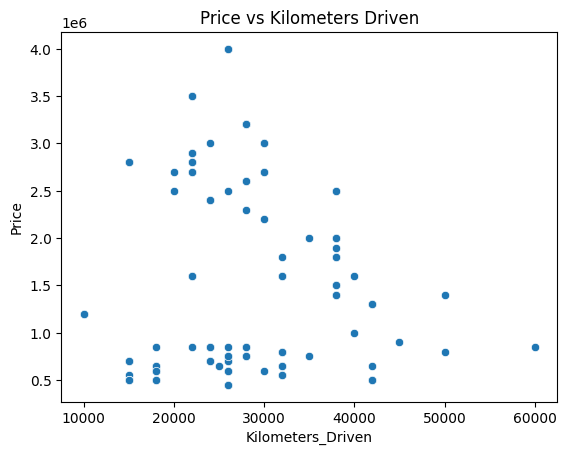

In [ ]:
sns.scatterplot(x="Kilometers_Driven", y="Price", data=cars)
plt.title("Price vs Kilometers Driven")
plt.show()

This plot shows a negative relationship. As the number of kilometers driven increases, the car price tends to decrease.

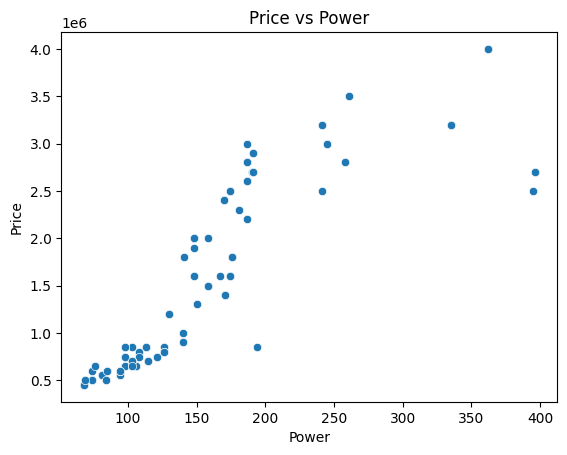

In [ ]:
sns.scatterplot(x="Power", y="Price", data=cars)
plt.title("Price vs Power")
plt.show()

This plot shows that cars with higher engine power usually have higher prices, indicating a strong positive relationship.

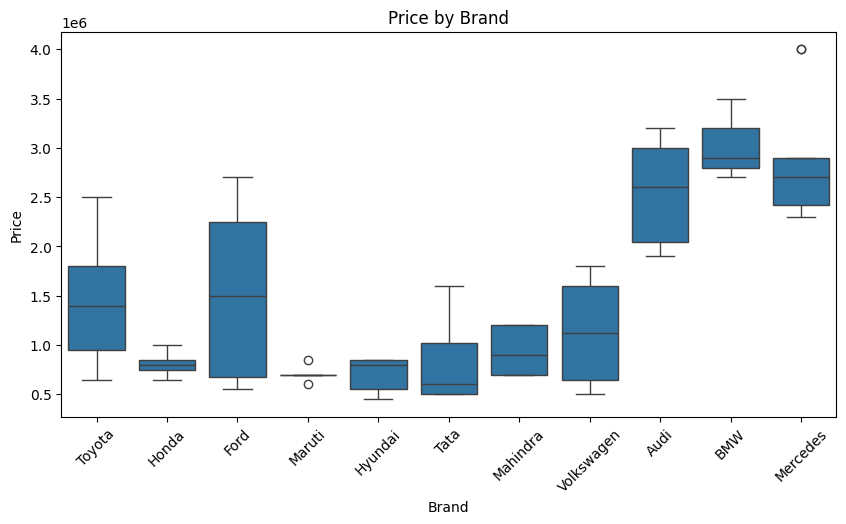

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(x="Brand", y="Price", data=cars)
plt.xticks(rotation=45)
plt.title("Price by Brand")
plt.show()

This plot compares prices across different brands. Some brands have higher median prices, showing that brand plays an important role in pricing.

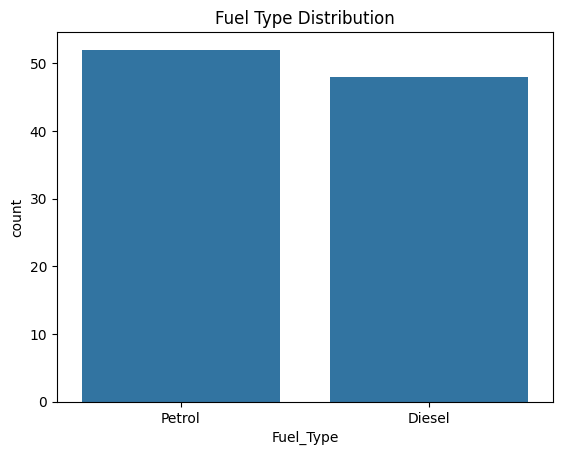

In [ ]:
sns.countplot(x="Fuel_Type", data=cars)
plt.title("Fuel Type Distribution")
plt.show()

This chart shows the count of cars by fuel type. It helps understand which fuel type is more common in the dataset


Correlation Heatmap

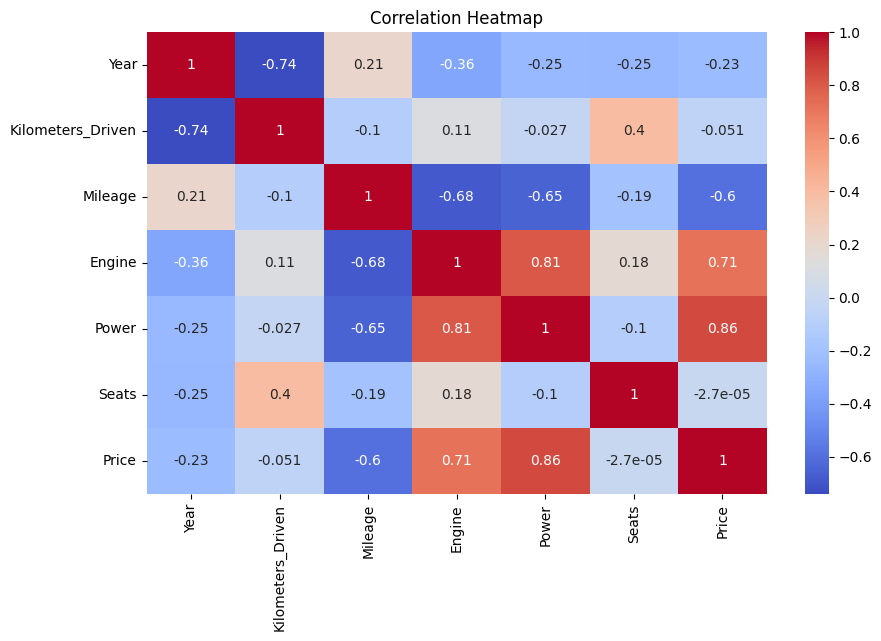

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(cars.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

The heatmap shows relationships between numerical features. Features like power, engine, and year have a strong correlation with price, meaning they significantly influence car price

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split data first (IMPORTANT)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create scaler
scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

Encoding - Convert categorical → numerical

In [ ]:
categorical_cols = cars.select_dtypes(include=['object', 'category']).columns

# Apply one-hot encoding only on categorical columns
cars_encoded = pd.get_dummies(cars, columns=categorical_cols, drop_first=True)

Split Data

In [ ]:
from sklearn.model_selection import train_test_split

X = cars_encoded.drop("Price", axis=1)
y = cars_encoded["Price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

Train Model (Linear Regression)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 118849.09987145364
MSE: 47391220104.1367
R2 Score: 0.9658620035627246


In [ ]:
print("Train Score:", model.score(X_train, y_train))
print("Test Score:", model.score(X_test, y_test))

Train Score: 1.0
Test Score: 0.9658620035627246


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

ridge = Ridge(alpha=1.0)  # increase alpha to reduce overfitting
ridge.fit(X_train, y_train)

y_pred = ridge.predict(X_test)

print("Train Score:", ridge.score(X_train, y_train))
print("Test Score:", ridge.score(X_test, y_test))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Train Score: 0.9876196406049602
Test Score: 0.911482135742526
MAE: 227219.87031091153
MSE: 122882712108.83176
R2 Score: 0.911482135742526


Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("RF R2 Score:", r2_score(y_test, y_pred_rf))

RF R2 Score: 0.9532080534495488


In [ ]:

train_score = rf.score(X_train, y_train)
print("Train R2 Score:", train_score)
print("Test R2 Score:", r2_score(y_test, y_pred_rf))

Train R2 Score: 0.9894750209297202
Test R2 Score: 0.9532080534495488


XGBRegressor

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Create model
xgb = XGBRegressor(n_estimators=100,learning_rate=0.1,max_depth=5,random_state=42)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("Test R2 Score:", r2_score(y_test, y_pred_xgb))
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("MSE:", mean_squared_error(y_test, y_pred_xgb))

Test R2 Score: 0.9834919571876526
MAE: 87996.015625
MSE: 22916864000.0


In [ ]:
print("Train R2 Score:", xgb.score(X_train, y_train))
print("Test R2 Score:", r2_score(y_test, y_pred_xgb))

Train R2 Score: 0.9999203085899353
Test R2 Score: 0.934860110282898


extra

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
rom xgboost import XGBRegressor

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBRegressor())
])

In [ ]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
cars = cars.drop_duplicates()

In [ ]:
numeric_data = cars.select_dtypes(include=['int64', 'float64'])

corr_matrix = numeric_data.corr()

print(corr_matrix)

                     Car_ID      Year  Kilometers_Driven   Mileage    Engine  \
Car_ID             1.000000  0.059904          -0.227442  0.026140 -0.027965   
Year               0.059904  1.000000          -0.741176  0.213177 -0.355122   
Kilometers_Driven -0.227442 -0.741176           1.000000 -0.104437  0.112340   
Mileage            0.026140  0.213177          -0.104437  1.000000 -0.680949   
Engine            -0.027965 -0.355122           0.112340 -0.680949  1.000000   
Power              0.027637 -0.249446          -0.026732 -0.648894  0.805709   
Seats             -0.021582 -0.252598           0.396443 -0.194581  0.179179   
Price              0.037105 -0.232687          -0.051104 -0.595252  0.714465   

                      Power     Seats     Price  
Car_ID             0.027637 -0.021582  0.037105  
Year              -0.249446 -0.252598 -0.232687  
Kilometers_Driven -0.026732  0.396443 -0.051104  
Mileage           -0.648894 -0.194581 -0.595252  
Engine             0.805709  

In [ ]:
cars.corr(numeric_only=True)

,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Price
Car_ID,1.000000,0.059904,-0.227442,0.026140,-0.027965,0.027637,-0.021582,0.037105
Year,0.059904,1.000000,-0.741176,0.213177,-0.355122,-0.249446,-0.252598,-0.232687
Kilometers_Driven,-0.227442,-0.741176,1.000000,-0.104437,0.112340,-0.026732,0.396443,-0.051104
Mileage,0.026140,0.213177,-0.104437,1.000000,-0.680949,-0.648894,-0.194581,-0.595252
Engine,-0.027965,-0.355122,0.112340,-0.680949,1.000000,0.805709,0.179179,0.714465
Power,0.027637,-0.249446,-0.026732,-0.648894,0.805709,1.000000,-0.102867,0.856620
Seats,-0.021582,-0.252598,0.396443,-0.194581,0.179179,-0.102867,1.000000,-0.000027
Price,0.037105,-0.232687,-0.051104,-0.595252,0.714465,0.856620,-0.000027,1.000000


In [ ]:
cars_encoded = cars.copy()

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cars_encoded.select_dtypes(include='object'):
    cars_encoded[col] = le.fit_transform(cars_encoded[col])

cars_encoded.corr()

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
Car_ID,1.000000,0.015205,0.053171,0.059904,-0.227442,0.088063,0.087118,0.049568,0.026140,-0.027965,0.027637,-0.021582,0.037105
Brand,0.015205,1.000000,0.194702,0.110875,0.082947,0.063037,0.187123,-0.079183,0.086441,-0.166709,-0.335425,0.114417,-0.354543
Model,0.053171,0.194702,1.000000,0.090754,0.011237,-0.059048,0.263721,0.088050,0.130721,-0.074587,-0.153203,-0.063274,-0.292434
Year,0.059904,0.110875,0.090754,1.000000,-0.741176,0.252843,0.211993,-0.036276,0.213177,-0.355122,-0.249446,-0.252598,-0.232687
Kilometers_Driven,-0.227442,0.082947,0.011237,-0.741176,1.000000,-0.323762,0.030157,-0.000560,-0.104437,0.112340,-0.026732,0.396443,-0.051104
Fuel_Type,0.088063,0.063037,-0.059048,0.252843,-0.323762,1.000000,0.066306,0.323325,-0.060292,-0.258043,-0.008562,-0.347549,-0.180964
Transmission,0.087118,0.187123,0.263721,0.211993,0.030157,0.066306,1.000000,0.097708,0.331015,-0.421374,-0.574349,0.111225,-0.676484
Owner_Type,0.049568,-0.079183,0.088050,-0.036276,-0.000560,0.323325,0.097708,1.000000,0.072823,-0.248205,-0.237857,-0.075318,-0.301488
Mileage,0.026140,0.086441,0.130721,0.213177,-0.104437,-0.060292,0.331015,0.072823,1.000000,-0.680949,-0.648894,-0.194581,-0.595252
Engine,-0.027965,-0.166709,-0.074587,-0.355122,0.112340,-0.258043,-0.421374,-0.248205,-0.680949,1.000000,0.805709,0.179179,0.714465


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(xgb, X, y, cv=5, scoring='r2')

print("Cross Validation Scores:", scores)
print("Average Score:", scores.mean())

Cross Validation Scores: [0.66520697 0.99893826 0.99059993 0.99535483 0.99989092]
Average Score: 0.9299981832504273


In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

xgb1 = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb1.fit(X_train, y_train)

y_pred_xgb = xgb1.predict(X_test)

print("Train R2 Score:", xgb1.score(X_train, y_train))
print("Test R2 Score:", r2_score(y_test, y_pred_xgb))
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("MSE:", mean_squared_error(y_test, y_pred_xgb))

Train R2 Score: 0.9999087452888489
Test R2 Score: 0.9677901864051819
MAE: 93101.703125
MSE: 44714434560.0


In [ ]:
import joblib
joblib.dump(xgb, 'xgb.pkl')
cat_cols = [
    'Brand',
    'Model',
    'Fuel_Type',
    'Transmission',
    'Owner_Type'
]

num_cols = [

    'Year',
    'Kilometers_Driven',
    'Mileage',
    'Engine',
    'Power',
    'Seats',

]

joblib.dump({
    'cat_cols': cat_cols,
    'num_cols': num_cols
}, 'columns.pkl')
print("✅ All files saved successfully!")

✅ All files saved successfully!


In [ ]:
from google.colab import files

files.download('xgb.pkl')


files.download('columns.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>